# Import Libraries Needed

In [4]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

In [5]:
def load_housing_data():
    tarball_path = Path('datasets/housing.tgz')
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents = True, exist_ok = True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

df = load_housing_data()

In [6]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


Note that there are 10 columns:
- `longitude`
- `latitude`
- `housing_median_age`
- `total_rooms`
- `total_bedrooms`
- `population`
- `households`
- `median_income`
- `median_house_value`
- `ocean_proximity`
and each row tells what district it belongs to.

The `info()` method is useful to get a quick description of the data, in particular the total number of rows, each attribute’s type, and the number of non-null values:

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


The dataset has 20,640 rows all has entries except for `total_bedrooms` which only has 20433 entries. So we need to take care of the missing values. Also, all the columns are numerical except for the `ocean_proximity`.

In [8]:
# Let us count how many possible categories are in ocean_proximity column.
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

The `describe()` method shows a summary of the numerical attributes.

In [9]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [10]:
import matplotlib.pyplot as plt

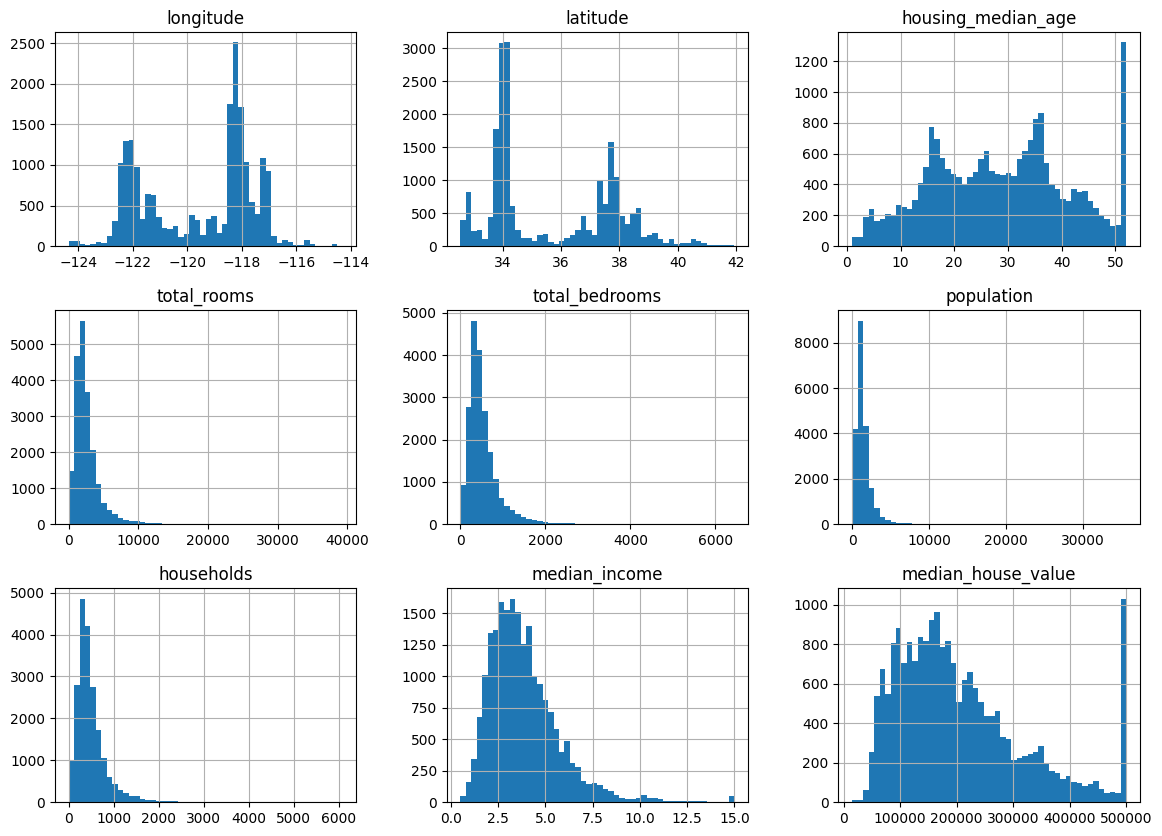

In [11]:
df.hist(bins=50, figsize=(14, 10))
plt.show()


### Way to split the dataset into train and test sets

In [12]:
import numpy as np
# np.random.seed(42)

# def shuffle_and_split_data(data, test_ratio):
#     shuffled_indices = np.random.permutation(len(data))
#     test_set_size = int(len(data)*test_ratio)
#     test_indices = shuffled_indices[:test_set_size]
#     train_indices = shuffled_indices[test_set_size:]
#     return data.iloc[train_indices], data.iloc[test_indices]

# train_set, test_set = shuffle_and_split_data(df, 0.2)
# print(len(train_set))
# print(len(test_set))

In [13]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

In [14]:
test_set["total_bedrooms"].isnull().sum()

44

The function `pd.cut()` allows us to cut a dataframe and labeled it according to a list of category.

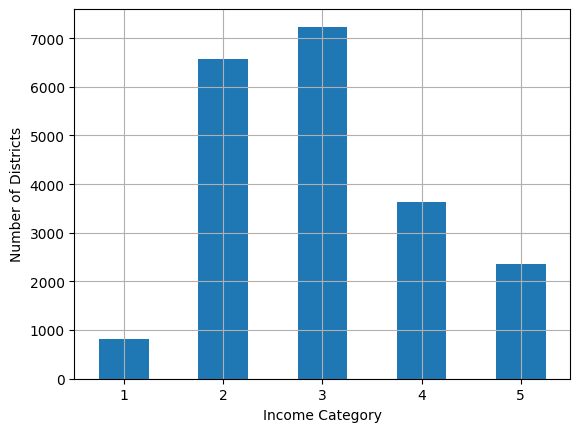

In [15]:
df['income_cat'] = pd.cut(df['median_income'],
                          bins = [0, 1.5, 3, 4.5, 6, np.Inf],
                          labels = [1, 2, 3, 4, 5])
df['income_cat'].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.xlabel('Income Category')
plt.ylabel('Number of Districts')
plt.show()

In [16]:
strat_train_set, strat_test_set = train_test_split(df, test_size=0.2, stratify=df['income_cat'], random_state=42)

In [17]:
strat_train_set['income_cat'].value_counts()/len(strat_train_set)

income_cat
3    0.350594
2    0.318859
4    0.176296
5    0.114462
1    0.039789
Name: count, dtype: float64

In [18]:
strat_test_set['income_cat'].value_counts()/len(strat_test_set)

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

In [19]:
for _ in (strat_train_set, strat_test_set):
    _.drop('income_cat', axis=1, inplace=True)

In [20]:
housing = strat_train_set.copy()

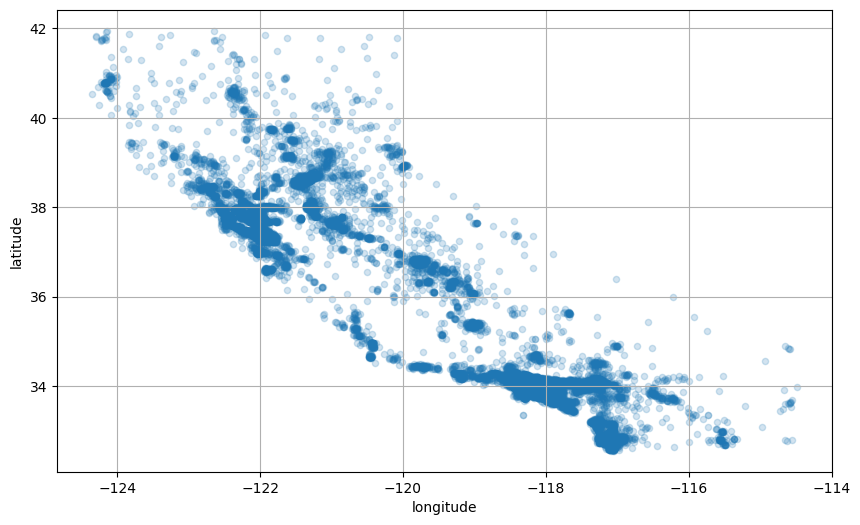

In [21]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True, alpha=0.2, figsize=(10,6))
plt.show()

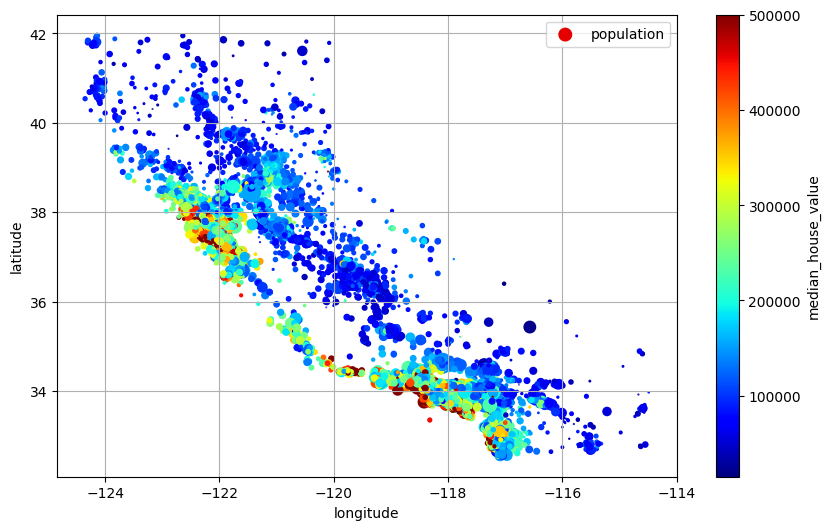

In [22]:
housing.plot(kind='scatter', x='longitude', y='latitude', grid=True,
             s=housing['population']/100, label='population',
             c='median_house_value', cmap='jet', colorbar=True,
             legend=True, sharex=False, figsize=(10,6))
plt.show()

In [23]:
corr_matrix = housing.select_dtypes(include='number').corr()
corr_matrix['median_house_value'].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64

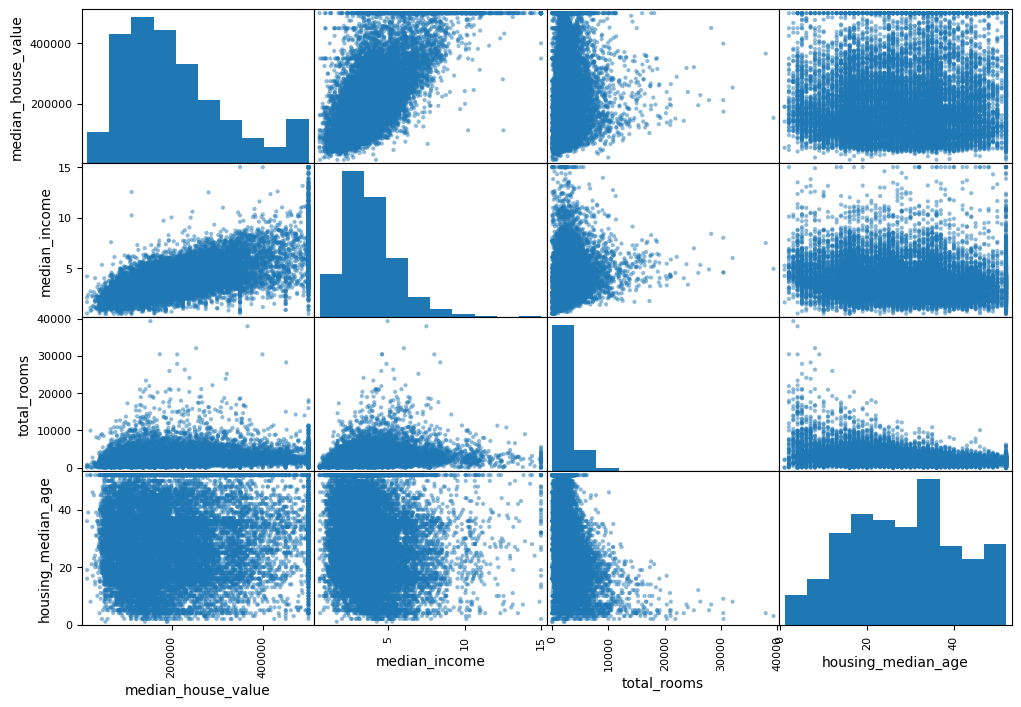

In [24]:
from pandas.plotting import scatter_matrix
attributes = ['median_house_value', 'median_income', 'total_rooms', 'housing_median_age']
scatter_matrix(housing[attributes], figsize=(12,8))
plt.show()

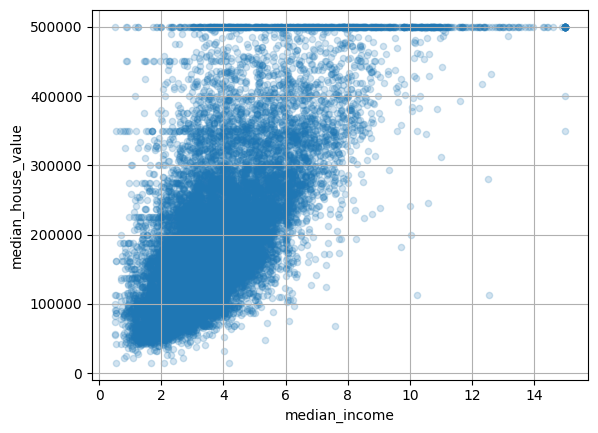

In [25]:
housing.plot(kind='scatter', x='median_income', y='median_house_value', grid=True, alpha=0.2)
plt.show()

In [26]:
housing.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

One last thing we may want to do before preparing the data for machine learning algorithms is to try out various attribute combinations.

In [27]:
housing['rooms_per_house'] = housing['total_rooms']/housing['households']
housing['bedrooms_ratio'] = housing['total_bedrooms']/housing['total_rooms']
housing['people_per_house'] = housing['population']/housing['households']

In [28]:
corr_matrix = housing.drop(columns = 'ocean_proximity', axis = 1).corr()
corr_matrix['median_house_value'].sort_values(ascending = False)

median_house_value    1.000000
median_income         0.688380
rooms_per_house       0.143663
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
people_per_house     -0.038224
longitude            -0.050859
latitude             -0.139584
bedrooms_ratio       -0.256397
Name: median_house_value, dtype: float64

The new `bedrooms_ratio` attribute is much more correlated with the
median house value than the total number of rooms or bedrooms. Apparently houses
with a lower bedroom/room ratio tend to be more expensive. The number of rooms
per household is also more informative than the total number of rooms in a district—
obviously the larger the houses, the more expensive they are.

## Prepare the Data for Machine Learning Algorithms

In [29]:
housing = strat_train_set.drop(columns='median_house_value', axis = 1)
housing_labels = strat_train_set['median_house_value'].copy()

Fix the missing values

In [30]:
# Option 1
# housing.dropna(subset=['total_bedrooms'], inplace=True)

# Option 2
# housing.drop(columns=['total_bedrooms'], axis=1)

# Option 3
# med = housing['total_bedrooms'].median()
# housing.fillna(value=med, axis=1, inplace=True)

In [31]:
# Option 4 is to use an imputer
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy = "median")

We can now use the imputer to the training data using `fit()` method after dropping non-numerical columns.

In [32]:
housing_num = housing.select_dtypes(include=[np.number])
imputer.fit(housing_num)

SimpleImputer(strategy='median')

`.values` gives a series??

In [33]:
imputer.statistics_
housing_num.median().values

# these are the same

array([-118.51  ,   34.26  ,   29.    , 2125.    ,  434.    , 1167.    ,
        408.    ,    3.5385])

In [34]:
X = imputer.transform(housing_num) # this is just a NumPy array, so we still need to wrap this in a DataFrame

In [35]:
housing_tr = pd.DataFrame(X, columns = housing_num.columns, index = housing_num.index)

In [36]:
housing_cat = housing[['ocean_proximity']]
housing_cat.head()

,ocean_proximity
13096,NEAR BAY
14973,<1H OCEAN
3785,INLAND
14689,INLAND
20507,NEAR OCEAN


In [37]:
from sklearn.preprocessing import OrdinalEncoder
ordinal_encoder = OrdinalEncoder()

In [38]:
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)
housing_cat_encoded[:5]

array([[3.],
       [0.],
       [1.],
       [1.],
       [4.]])

In [39]:
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

Another way to encode categorical variables is to use one-hot encoding

In [40]:
from sklearn.preprocessing import OneHotEncoder
cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat) # this gives us a SciPy sparse matrix

In [41]:
housing_cat_1hot.toarray()

array([[0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.]])

We can also use the `get_dummies()` function in pandas 

In [42]:
df_test = pd.DataFrame({'ocean_proximity': ['INLAND', 'NEAR_BAY']})
pd.get_dummies(df_test)

,ocean_proximity_INLAND,ocean_proximity_NEAR_BAY
0,True,False
1,False,True


In [43]:
cat_encoder.feature_names_in_

array(['ocean_proximity'], dtype=object)

In [44]:
cat_encoder.get_feature_names_out()

array(['ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'], dtype=object)

## Feature Scaling and Transformation

min-max scaling and standard scaling

In [45]:
from sklearn.preprocessing import MinMaxScaler
min_max_scaler = MinMaxScaler(feature_range=(-1,1))
housing_num_min_max_scaled=min_max_scaler.fit_transform(housing_num)

In [46]:
housing_num_min_max_scaled

array([[-0.60851927,  0.11702128,  1.        , ..., -0.80701754,
        -0.61433638, -0.7794789 ],
       [ 0.21095335, -0.66170213,  0.52941176, ..., -0.91866029,
        -0.86708979, -0.22929339],
       [-0.51926978,  0.23617021,  0.25490196, ..., -0.93141946,
        -0.92458466, -0.73336919],
       ...,
       [ 0.47870183, -0.99148936, -0.52941176, ..., -0.65513434,
        -0.71663244, -0.50873781],
       [ 0.20689655, -0.6787234 ,  0.41176471, ..., -0.78873758,
        -0.68751167, -0.49716556],
       [-0.60649087,  0.08723404,  0.68627451, ..., -0.91669734,
        -0.92122457, -0.61608805]])

In [47]:
from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()
housing_num_std_scaled = std_scaler.fit_transform(housing_num)

In [48]:
from sklearn.metrics.pairwise import rbf_kernel
age_simil_35_gamma1 = rbf_kernel(housing[['housing_median_age']], [[35]], gamma=0.1)
age_simil_35_gamma2 = rbf_kernel(housing[['housing_median_age']], [[35]], gamma=0.03)

In [49]:
from sklearn.preprocessing import FunctionTransformer
log_transformer = FunctionTransformer(np.log, inverse_func=np.exp)
log_pop = log_transformer.transform(housing[["population"]])

In [50]:
rbf_transformer = FunctionTransformer(rbf_kernel, kw_args=dict(Y=[[35.]], gamma=0.1))
age_simil_35 = rbf_transformer.transform(housing[['housing_median_age']])

## Custom Transformers

In [51]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_array, check_is_fitted

class StandardScalerClone(BaseEstimator, TransformerMixin):
    def __init__(self, with_mean=True): # no *args or **kwargs!
        self.with_mean = with_mean
    def fit(self, X, y=None): # y is required even though we don't use it
        X = check_array(X) # checks that X is an array with finite float values
        self.mean_ = X.mean(axis=0)
        self.scale_ = X.std(axis=0)
        self.n_features_in_ = X.shape[1] # every estimator stores this in fit()
        return self # always return self!
    def transform(self, X):
        check_is_fitted(self) # looks for learned attributes (with trailing _)
        X = check_array(X)
        assert self.n_features_in_ == X.shape[1]
        if self.with_mean:
            X = X - self.mean_
        return X / self.scale_

In [52]:
from sklearn.cluster import KMeans

class ClusterSimilarity(BaseEstimator, TransformerMixin):
	def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
		self.n_clusters = n_clusters
		self.gamma = gamma
		self.random_state = random_state
		
	def fit(self, X, y=None, sample_weight=None):
		self.kmeans_ = KMeans(self.n_clusters, random_state=self.random_state)
		self.kmeans_.fit(X, sample_weight=sample_weight)
		return self # always return self!
		
	def transform(self, X):
		return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)
		
	def get_feature_names_out(self, names=None):
		return [f"Cluster {i} similarity" for i in range(self.n_clusters)]

In [53]:
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)
similarities = cluster_simil.fit_transform(housing[["latitude", "longitude"]], sample_weight=housing_labels)

In [54]:
similarities[:3].round(2)

array([[0.  , 0.98, 0.  , 0.  , 0.  , 0.  , 0.13, 0.55, 0.  , 0.56],
       [0.64, 0.  , 0.11, 0.04, 0.  , 0.  , 0.  , 0.  , 0.99, 0.  ],
       [0.  , 0.65, 0.  , 0.  , 0.01, 0.  , 0.49, 0.59, 0.  , 0.28]])

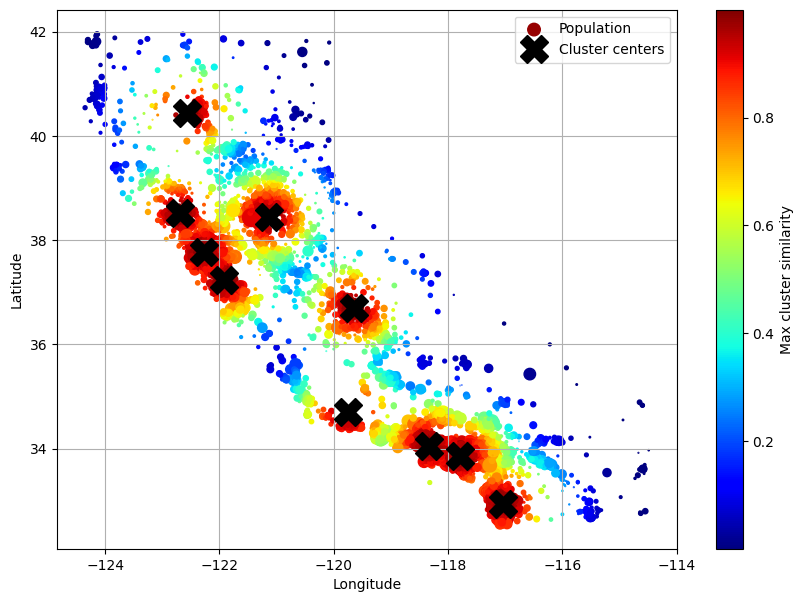

In [55]:
# extra code – this cell generates Figure 2–19

housing_renamed = housing.rename(columns={
    "latitude": "Latitude", "longitude": "Longitude",
    "population": "Population",
    "median_house_value": "Median house value (ᴜsᴅ)"})
housing_renamed["Max cluster similarity"] = similarities.max(axis=1)

housing_renamed.plot(kind="scatter", x="Longitude", y="Latitude", grid=True,
                     s=housing_renamed["Population"] / 100, label="Population",
                     c="Max cluster similarity",
                     cmap="jet", colorbar=True,
                     legend=True, sharex=False, figsize=(10, 7))
plt.plot(cluster_simil.kmeans_.cluster_centers_[:, 1],
         cluster_simil.kmeans_.cluster_centers_[:, 0],
         linestyle="", color="black", marker="X", markersize=20,
         label="Cluster centers")
plt.legend(loc="upper right")
plt.show()

## Transformation Pipelines

Scikit-Learn provides the Pipeline class to help with such sequences of transformations.

In [56]:
from sklearn.pipeline import Pipeline

num_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('standardize', StandardScaler())
])

The `Pipeline` constructor takes a list of name/estimator pairs (2-tuples) defining a sequence of steps. The names can be anything you like, as long as they are unique and don’t contain double underscores (__).

In [57]:
from sklearn import set_config

set_config(display = 'diagram')
num_pipeline

Pipeline(steps=[('impute', SimpleImputer(strategy='median')),
                ('standardize', StandardScaler())])

If you don’t want to name the transformers, you can use the `make_pipeline()` function instead;

In [58]:
from sklearn.pipeline import make_pipeline
#num_pipeline = make_pipeline(SimpleImputer(strategy='median'), StandardScaler())

When you call the pipeline’s `fit()` method, it calls `fit_transform()` sequentially on all the transformers, passing the output of each call as the parameter to the next call until it reaches the final estimator, for which it just calls the `fit()` method

In [59]:
housing_num.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
13096,-122.42,37.80,52.0,3321.0,1115.0,1576.0,1034.0,2.0987
14973,-118.38,34.14,40.0,1965.0,354.0,666.0,357.0,6.0876
3785,-121.98,38.36,33.0,1083.0,217.0,562.0,203.0,2.4330
14689,-117.11,33.75,17.0,4174.0,851.0,1845.0,780.0,2.2618
20507,-118.15,33.77,36.0,4366.0,1211.0,1912.0,1172.0,3.5292


In [60]:
housing_num_prepared = num_pipeline.fit_transform(housing_num)
housing_num_prepared[:2].round(2)

array([[-1.42,  1.01,  1.86,  0.31,  1.37,  0.14,  1.39, -0.94],
       [ 0.6 , -0.7 ,  0.91, -0.31, -0.44, -0.69, -0.37,  1.17]])

In [61]:
df_housing_num_prepared = pd.DataFrame(housing_num_prepared, columns = num_pipeline.get_feature_names_out(), index = housing_num.index)

In [62]:
df_housing_num_prepared.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
13096,-1.423037,1.013606,1.861119,0.311912,1.368167,0.137460,1.394812,-0.936491
14973,0.596394,-0.702103,0.907630,-0.308620,-0.435925,-0.693771,-0.373485,1.171942
3785,-1.203098,1.276119,0.351428,-0.712240,-0.760709,-0.788768,-0.775727,-0.759789
14689,1.231216,-0.884924,-0.919891,0.702262,0.742306,0.383175,0.731375,-0.850281
20507,0.711362,-0.875549,0.589800,0.790125,1.595753,0.444376,1.755263,-0.180365


In [63]:
from sklearn.compose import ColumnTransformer

num_attribs = ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
cat_attribs = ['ocean_proximity']

In [64]:
cat_pipeline = make_pipeline(SimpleImputer(strategy='most_frequent'), OneHotEncoder(handle_unknown='ignore'))

preprocessing = ColumnTransformer([
    ('num', num_pipeline, num_attribs),
    ('cat', cat_pipeline, cat_attribs)
])

Since listing all the column names is not very convenient, Scikit-Learn provides a `make_column_selector()` function that returns a selector function you can use to automatically select all the features of a given type, such as numerical or categorical.

In [65]:
from sklearn.compose import make_column_selector, make_column_transformer

preprocessing = make_column_transformer(
    (num_pipeline, make_column_selector(dtype_include=np.number)),
    (cat_pipeline, make_column_selector(dtype_include=object)),
)

In [66]:
housing_prepared = preprocessing.fit_transform(housing)
housing_prepared[:2]

array([[-1.42303652,  1.0136059 ,  1.86111875,  0.31191221,  1.36816703,
         0.13746004,  1.39481249, -0.93649149,  0.        ,  0.        ,
         0.        ,  1.        ,  0.        ],
       [ 0.59639445, -0.702103  ,  0.90762971, -0.30861991, -0.43592476,
        -0.69377062, -0.37348471,  1.17194198,  1.        ,  0.        ,
         0.        ,  0.        ,  0.        ]])

In [67]:
df_housing_prepared = pd.DataFrame(housing_prepared, columns = preprocessing.get_feature_names_out(), index = housing.index)

In [68]:
df_housing_prepared.head()

,pipeline-1__longitude,pipeline-1__latitude,pipeline-1__housing_median_age,pipeline-1__total_rooms,pipeline-1__total_bedrooms,pipeline-1__population,pipeline-1__households,pipeline-1__median_income,pipeline-2__ocean_proximity_<1H OCEAN,pipeline-2__ocean_proximity_INLAND,pipeline-2__ocean_proximity_ISLAND,pipeline-2__ocean_proximity_NEAR BAY,pipeline-2__ocean_proximity_NEAR OCEAN
13096,-1.423037,1.013606,1.861119,0.311912,1.368167,0.137460,1.394812,-0.936491,0.0,0.0,0.0,1.0,0.0
14973,0.596394,-0.702103,0.907630,-0.308620,-0.435925,-0.693771,-0.373485,1.171942,1.0,0.0,0.0,0.0,0.0
3785,-1.203098,1.276119,0.351428,-0.712240,-0.760709,-0.788768,-0.775727,-0.759789,0.0,1.0,0.0,0.0,0.0
14689,1.231216,-0.884924,-0.919891,0.702262,0.742306,0.383175,0.731375,-0.850281,0.0,1.0,0.0,0.0,0.0
20507,0.711362,-0.875549,0.589800,0.790125,1.595753,0.444376,1.755263,-0.180365,0.0,0.0,0.0,0.0,1.0


In [ ]:
def column_ratio(X):
    return X[:, [0]] / X[:, [1]]

def ratio_name(function_transformer, feature_names_in):
    return ["ratio"]  # feature names out

def ratio_pipeline():
    return make_pipeline(
        SimpleImputer(strategy="median"),
        FunctionTransformer(column_ratio, feature_names_out=ratio_name),
        StandardScaler())

log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(np.log, feature_names_out="one-to-one"),
    StandardScaler())

cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)

default_num_pipeline = make_pipeline(SimpleImputer(strategy="median"),
                                     StandardScaler())
preprocessing = ColumnTransformer([
        ("bedrooms", ratio_pipeline(), ["total_bedrooms", "total_rooms"]),
        ("rooms_per_house", ratio_pipeline(), ["total_rooms", "households"]),
        ("people_per_house", ratio_pipeline(), ["population", "households"]),
        ("log", log_pipeline, ["total_bedrooms", "total_rooms", "population",
                               "households", "median_income"]),
        ("geo", cluster_simil, ["latitude", "longitude"]),
        ("cat", cat_pipeline, make_column_selector(dtype_include=object)),
    ],
    remainder=default_num_pipeline)  # one column remaining: housing_median_age

In [70]:
housing_prepared = preprocessing.fit_transform(housing)
housing_prepared.shape

(16512, 24)

In [71]:
preprocessing.get_feature_names_out()

array(['bedrooms__ratio', 'rooms_per_house__ratio',
       'people_per_house__ratio', 'log__total_bedrooms',
       'log__total_rooms', 'log__population', 'log__households',
       'log__median_income', 'geo__Cluster 0 similarity',
       'geo__Cluster 1 similarity', 'geo__Cluster 2 similarity',
       'geo__Cluster 3 similarity', 'geo__Cluster 4 similarity',
       'geo__Cluster 5 similarity', 'geo__Cluster 6 similarity',
       'geo__Cluster 7 similarity', 'geo__Cluster 8 similarity',
       'geo__Cluster 9 similarity', 'cat__ocean_proximity_<1H OCEAN',
       'cat__ocean_proximity_INLAND', 'cat__ocean_proximity_ISLAND',
       'cat__ocean_proximity_NEAR BAY', 'cat__ocean_proximity_NEAR OCEAN',
       'remainder__housing_median_age'], dtype=object)

In [72]:
df_housing_prepared = pd.DataFrame(housing_prepared, columns = preprocessing.get_feature_names_out(), index = housing.index)

In [73]:
df_housing_prepared.head()

,bedrooms__ratio,rooms_per_house__ratio,people_per_house__ratio,log__total_bedrooms,log__total_rooms,log__population,log__households,log__median_income,geo__Cluster 0 similarity,geo__Cluster 1 similarity,geo__Cluster 2 similarity,geo__Cluster 3 similarity,geo__Cluster 4 similarity,geo__Cluster 5 similarity,geo__Cluster 6 similarity,geo__Cluster 7 similarity,geo__Cluster 8 similarity,geo__Cluster 9 similarity,cat__ocean_proximity_<1H OCEAN,cat__ocean_proximity_INLAND,cat__ocean_proximity_ISLAND,cat__ocean_proximity_NEAR BAY,cat__ocean_proximity_NEAR OCEAN,remainder__housing_median_age
13096,1.846624,-0.866027,-0.330204,1.324114,0.637892,0.456906,1.310369,-1.071522,4.581829e-01,1.241847e-14,8.141160e-02,3.434950e-24,3.329278e-07,2.095028e-04,8.489216e-04,9.770322e-01,2.382191e-08,3.819126e-18,0.0,0.0,0.0,1.0,0.0,1.861119
14973,-0.508121,0.024550,-0.253616,-0.252671,-0.063576,-0.711654,-0.142030,1.194712,6.511495e-10,9.579596e-01,8.649502e-14,2.712990e-02,3.992038e-02,2.078914e-04,5.614049e-27,1.260964e-13,1.103491e-01,3.547610e-01,1.0,0.0,0.0,0.0,0.0,0.907630
3785,-0.202155,-0.041193,-0.051041,-0.925266,-0.859927,-0.941997,-0.913030,-0.756981,3.432506e-01,4.261141e-15,4.483096e-01,1.041079e-24,5.084725e-08,4.108863e-04,5.641131e-03,7.303265e-01,2.508224e-08,2.669659e-18,0.0,1.0,0.0,0.0,0.0,0.351428
14689,-0.149006,-0.034858,-0.141475,0.952773,0.943475,0.670700,0.925373,-0.912253,2.244844e-15,2.704823e-01,2.813014e-19,4.649510e-01,5.823840e-05,1.595594e-07,5.913326e-35,5.201263e-20,1.712982e-03,8.874598e-01,0.0,1.0,0.0,0.0,0.0,-0.919891
20507,0.963208,-0.666554,-0.306148,1.437622,1.003590,0.719093,1.481464,0.034537,1.090228e-11,9.422206e-01,6.016730e-16,1.092616e-01,9.773465e-03,1.371210e-05,5.421817e-30,1.048030e-15,2.568824e-02,5.279506e-01,0.0,0.0,0.0,0.0,1.0,0.589800


In [74]:
from sklearn.linear_model import LinearRegression

lin_reg = make_pipeline(preprocessing, LinearRegression())
lin_reg.fit(housing, housing_labels) # housing is your X and housing_labels is your y

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x155...
                                                   'households',
                                                   'median_income']),
                                                 ('geo',
                                                  ClusterSimilarity(random_state=42),
                                                  ['latitude', 'longitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x1559abe30>)])),
                ('linearregression', LinearRegression())])

In [75]:
housing_predictions = lin_reg.predict(housing)

In [76]:
housing_predictions[:5].round(-2)

array([246000., 372700., 135700.,  91400., 330900.])

In [77]:
housing_labels.iloc[:5].values

array([458300., 483800., 101700.,  96100., 361800.])

In [78]:
from sklearn.metrics import mean_squared_error
import numpy as np

lin_mse = mean_squared_error(housing_labels, housing_predictions)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

68972.88910758459

The RMSE is too high! The model is underfit. We can try adding more features or consider trying a more powerful model. Let us try DecisionTreeRegressor, a powerful model capable of finding complex nonlinear relationships in the data.

In [79]:
from sklearn.tree import DecisionTreeRegressor
tree_reg = make_pipeline(preprocessing, DecisionTreeRegressor(random_state=42))
tree_reg.fit(housing, housing_labels)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x155...
                                                 ('geo',
                                                  ClusterSimilarity(random_state=42),
                                                  ['latitude', 'longitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x1559abe30>)])),
                ('decisiontreeregressor',
                 DecisionTreeRegressor(random_state=42))])

In [80]:
housing_predictions = tree_reg.predict(housing)
tree_mse = mean_squared_error(housing_labels, housing_predictions)
tree_rms = np.sqrt(tree_mse)
tree_rms

0.0

It is much more likely that the model has badly overfit the data.

In [81]:
from sklearn.model_selection import cross_val_score
tree_rmses = -cross_val_score(tree_reg, housing, housing_labels, scoring = 'neg_root_mean_squared_error', cv=10)

What `cross_val_score` from scikit-learn expects is that it is maximizing a utility (scoring) function. But since RMSE is a loss function, we want to minimize the scores. Hence, we apply the negative multiplication.

In [82]:
tree_rmses

array([64607.89604624, 66409.0627187 , 66203.41031283, 65863.76434319,
       68086.79141027, 66534.53308312, 66923.49892937, 68532.21066423,
       66367.48227837, 66208.69621463])

In [83]:
pd.Series(tree_rmses).describe()

count       10.000000
mean     66573.734600
std       1103.402323
min      64607.896046
25%      66204.731788
50%      66388.272499
75%      66826.257468
max      68532.210664
dtype: float64

Now the decision tree doesn’t look as good as it did earlier. In fact, it seems to perform almost as poorly as the linear regression model! We know there’s an overfitting problem because the training error is low (actually zero) while the validation error is high.

Let us try one last model, `RandomForestRegressor`

In [84]:
from sklearn.ensemble import RandomForestRegressor
forest_reg = make_pipeline(preprocessing, RandomForestRegressor(random_state=42))
forest_reg.fit(housing, housing_labels)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x155...
                                                 ('geo',
                                                  ClusterSimilarity(random_state=42),
                                                  ['latitude', 'longitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x1559abe30>)])),
                ('randomforestregressor',
                 RandomForestRegressor(random_state=42))])

In [85]:
forest_rmses = cross_val_score(forest_reg, housing, housing_labels, scoring='neg_root_mean_squared_error', cv=10)

In [86]:
forest_rmses = -forest_rmses

In [87]:
pd.Series(forest_rmses).describe()

count       10.000000
mean     47038.092799
std       1021.491757
min      45495.976649
25%      46510.418013
50%      47118.719249
75%      47480.519175
max      49140.832210
dtype: float64

### Fine-tune Model using GridSearchCV

In [88]:
from sklearn.model_selection import GridSearchCV

full_pipeline = Pipeline([
    ('preprocessing', preprocessing),
    ('random_forest', RandomForestRegressor(random_state=42))
])

# Create a dictionary to try different values of hyperparameters
param_grid = [
    {'preprocessing__geo__n_clusters' : [5, 8, 10],
    'random_forest__max_features' : [4, 6, 8]},
    {'preprocessing__geo__n_clusters' : [10, 15, 20],
    'random_forest__max_features' : [6, 8, 10]},
]

grid_search = GridSearchCV(full_pipeline, param_grid, cv=3, scoring='neg_root_mean_squared_error')
grid_search.fit(housing, housing_labels)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                                                     SimpleImputer(strategy='median')),
                                                                                    ('standardscaler',
                                                                                     StandardScaler())]),
                                                          transformers=[('bedrooms',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('functiontransformer',
                                                                                          FunctionTransformer(feature_names_out=<f...
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x1559abe30>)])),
                                       ('random_forest',
                                        RandomForestRegressor(random_state=42))]),
             param_grid=[{'preprocessing__geo__n_clusters': [5, 8, 10],
                          'random_forest__max_features': [4, 6, 8]},
                         {'preprocessing__geo__n_clusters': [10, 15, 20],
                          'random_forest__max_features': [6, 8, 10]}],
             scoring='neg_root_mean_squared_error')

In [89]:
grid_search.best_params_

{'preprocessing__geo__n_clusters': 20, 'random_forest__max_features': 6}

In [90]:
grid_search.best_estimator_

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x1557fa2...
                                                  ClusterSimilarity(n_clusters=20,
                                                                    random_state=42),
                                                  ['latitude', 'longitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x1558513a0>)])),
                ('random_forest',
                 RandomForestRegressor(max_features=6, random_state=42))])

In [91]:
cv_res = pd.DataFrame(grid_search.cv_results_)
cv_res.sort_values(by = 'mean_test_score', ascending=False, inplace=True)
cv_res = cv_res[["param_preprocessing__geo__n_clusters",
                 "param_random_forest__max_features", "split0_test_score",
                 "split1_test_score", "split2_test_score", "mean_test_score"]]
score_cols = ["split0", "split1", "split2", "mean_test_rmse"]
cv_res.columns = ["n_clusters", "max_features"] + score_cols
cv_res[score_cols] = -cv_res[score_cols].round().astype(np.int64)

cv_res.head()

,n_clusters,max_features,split0,split1,split2,mean_test_rmse
15,20,6,41997,43051,43639,42896
16,20,8,42587,43232,43983,43267
12,15,6,42725,43710,44335,43590
17,20,10,43056,43744,44363,43721
13,15,8,43487,43813,44900,44066


### Fine-tune Model using Random Search

In [92]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distribs = {'preprocessing__geo__n_clusters' : randint(low=3, high=50),
                  'random_forest__max_features' : randint(low=2, high=20)}

rnd_search = RandomizedSearchCV(full_pipeline, param_distributions=param_distribs, n_iter=10, cv=3, scoring='neg_root_mean_squared_error', random_state=42)

rnd_search.fit(housing, housing_labels)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                                                           SimpleImputer(strategy='median')),
                                                                                          ('standardscaler',
                                                                                           StandardScaler())]),
                                                                transformers=[('bedrooms',
                                                                               Pipeline(steps=[('simpleimputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('functiontransformer',
                                                                                                FunctionTransformer(feature_names_...
                                                                               <sklearn.compose._column_transformer.make_column_selector object at 0x1559abe30>)])),
                                             ('random_forest',
                                              RandomForestRegressor(random_state=42))]),
                   param_distributions={'preprocessing__geo__n_clusters': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x1554ab200>,
                                        'random_forest__max_features': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x155aa7920>},
                   random_state=42, scoring='neg_root_mean_squared_error')

Let us see how important each feature is from the Random Search

In [93]:
final_model = rnd_search.best_estimator_
feature_importances = final_model['random_forest'].feature_importances_
feature_importances.round(2)

array([0.07, 0.05, 0.05, 0.01, 0.01, 0.01, 0.01, 0.19, 0.01, 0.02, 0.01,
       0.01, 0.01, 0.  , 0.01, 0.02, 0.01, 0.02, 0.01, 0.  , 0.01, 0.01,
       0.01, 0.01, 0.01, 0.  , 0.02, 0.01, 0.01, 0.  , 0.01, 0.01, 0.01,
       0.03, 0.01, 0.01, 0.01, 0.01, 0.04, 0.01, 0.02, 0.01, 0.02, 0.01,
       0.02, 0.02, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.  , 0.07,
       0.  , 0.  , 0.  , 0.01])

In [94]:
sorted(zip(feature_importances, final_model['preprocessing'].get_feature_names_out()), reverse=True)

[(0.18673440937412847, 'log__median_income'),
 (0.0732445627048804, 'cat__ocean_proximity_INLAND'),
 (0.06573054277260683, 'bedrooms__ratio'),
 (0.05353772260040246, 'rooms_per_house__ratio'),
 (0.04599485538141581, 'people_per_house__ratio'),
 (0.04179425251060039, 'geo__Cluster 30 similarity'),
 (0.026183337424678557, 'geo__Cluster 25 similarity'),
 (0.02360324145452081, 'geo__Cluster 36 similarity'),
 (0.020251090077874144, 'geo__Cluster 9 similarity'),
 (0.018195697534088156, 'geo__Cluster 34 similarity'),
 (0.018038462557457245, 'geo__Cluster 37 similarity'),
 (0.017213947543904626, 'geo__Cluster 18 similarity'),
 (0.016926670763984637, 'geo__Cluster 1 similarity'),
 (0.015435321619886467, 'geo__Cluster 7 similarity'),
 (0.015316340720864309, 'geo__Cluster 32 similarity'),
 (0.014949873958986105, 'geo__Cluster 13 similarity'),
 (0.014237369349325044, 'geo__Cluster 35 similarity'),
 (0.01389482192705414, 'geo__Cluster 0 similarity'),
 (0.01377584214096381, 'geo__Cluster 3 similarit

In [95]:
cv_res = pd.DataFrame(rnd_search.cv_results_)
cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)
cv_res = cv_res[["param_preprocessing__geo__n_clusters",
                 "param_random_forest__max_features", "split0_test_score",
                 "split1_test_score", "split2_test_score", "mean_test_score"]]
cv_res.columns = ["n_clusters", "max_features"] + score_cols
cv_res[score_cols] = -cv_res[score_cols].round().astype(np.int64)
cv_res.head()

,n_clusters,max_features,split0,split1,split2,mean_test_rmse
1,45,9,41342,42242,43107,42230
8,32,7,41808,42288,43244,42447
0,41,16,42238,42938,43354,42843
5,42,4,41884,43380,43706,42990
2,23,8,42473,42950,43725,43049


Let us drop the least important features.

In [96]:
# from sklearn.feature_selection import SelectFromModel

# # create a new pipeline with feature_selection
# fs_pipeline = Pipeline([
#     ("preprocessing", preprocessing),
#     ("feature_selection", SelectFromModel(RandomForestRegressor(random_state=42), threshold='median')),
#     ("random_forest", RandomForestRegressor(random_state=42))
# ])

In [97]:
# param_distribs = {
#     'preprocessing__geo__n_clusters': randint(3, 50),
#     'random_forest__max_features': randint(2, 20)
# }

# rnd_search_fs = RandomizedSearchCV(
#     fs_pipeline,
#     param_distributions=param_distribs,
#     n_iter=10,
#     cv=3,
#     scoring='neg_root_mean_squared_error',
#     random_state=42
# )

# rnd_search_fs.fit(housing, housing_labels)

In [98]:
# final_model = rnd_search_fs.best_estimator_
# feature_importances = final_model['random_forest'].feature_importances_
# feature_importances.round(2)
# sorted(zip(feature_importances, final_model['preprocessing'].get_feature_names_out()), reverse=True)

In [99]:
# cv_res = pd.DataFrame(rnd_search_fs.cv_results_)
# cv_res.sort_values(by = 'mean_test_score', ascending=False, inplace=True)
# cv_res = cv_res[["param_preprocessing__geo__n_clusters",
#                  "param_random_forest__max_features", "split0_test_score",
#                  "split1_test_score", "split2_test_score", "mean_test_score"]]
# score_cols = ["split0", "split1", "split2", "mean_test_rmse"]
# cv_res.columns = ["n_clusters", "max_features"] + score_cols
# cv_res[score_cols] = -cv_res[score_cols].round().astype(np.int64)

# cv_res.head()

## Evaluate your System on the Test Set

In [100]:
X_test = strat_test_set.drop('median_house_value', axis = 1)
y_test = strat_test_set['median_house_value'].copy()

In [101]:
final_predictions = final_model.predict(X_test)
final_mse = mean_squared_error(y_test, final_predictions)
final_rmse = np.sqrt(final_mse)
final_rmse

41448.084299370465

Get the confidence interval!

In [102]:
from scipy import stats

confidence = 0.95
squared_errors = (final_predictions-y_test) ** 2
np.sqrt(stats.t.interval(confidence, len(squared_errors)-1, loc=squared_errors.mean(), scale=stats.sem(squared_errors)))

array([39293.29060201, 43496.26073402])

## Launch, Monitor, and Maintain Your System

In [103]:
import joblib
joblib.dump(final_model, 'my_california_housing_model.pkl')

['my_california_housing_model.pkl']

In [104]:
# extra code – excluded for conciseness
from sklearn.cluster import KMeans
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics.pairwise import rbf_kernel

def column_ratio(X):
    return X[:, [0]] / X[:, [1]]

#class ClusterSimilarity(BaseEstimator, TransformerMixin):
#    [...]

final_model_reloaded = joblib.load("my_california_housing_model.pkl")

new_data = housing.iloc[:5]  # pretend these are new districts
predictions = final_model_reloaded.predict(new_data)
predictions

array([441046.12, 453580.08, 105067.  , 101316.  , 336181.05])

# Exercises

1. Try a Support Vector Machine regressor (`sklearn.svm.SVR`) with various hyperparameters, such as `kernel="linear"` (with various values for the `C` hyperparameter) or `kernel="rbf"` (with various values for the `C` and `gamma` hyperparameters). Note that SVMs don't scale well to large datasets, so you should probably train your model on just the first 5,000 instances of the training set and use only 3-fold cross-validation, or else it will take hours. Don't worry about what the hyperparameters mean for now (see the SVM notebook if you're interested). How does the best `SVR` predictor perform?

In [124]:
from sklearn.svm import SVR

full_pipeline = Pipeline([
    ('preprocessing', preprocessing),
    ('svr', SVR())
])

param_grid = [
    {'svr__kernel' : ['linear'], 'svr__C' : [0.1, 0.3, 0.5, 1, 3, 5, 100, 1000]},
    {'svr__kernel': ['rbf'], 'svr__C' : [0.1, 0.3, 0.5, 1], 'svr__gamma' : [0.01, 0.05, 0.1, 0.05]}
]

grid_search = GridSearchCV(full_pipeline, param_grid, cv=3, scoring='neg_root_mean_squared_error')
grid_search.fit(housing.iloc[:5000], housing_labels.iloc[:5000])


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                                                     SimpleImputer(strategy='median')),
                                                                                    ('standardscaler',
                                                                                     StandardScaler())]),
                                                          transformers=[('bedrooms',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('functiontransformer',
                                                                                          FunctionTransformer(feature_names_out=<f...
                                                                                         ('onehotencoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x1559abe30>)])),
                                       ('svr', SVR())]),
             param_grid=[{'svr__C': [0.1, 0.3, 0.5, 1, 3, 5, 100, 1000],
                          'svr__kernel': ['linear']},
                         {'svr__C': [0.1, 0.3, 0.5, 1],
                          'svr__gamma': [0.01, 0.05, 0.1, 0.05],
                          'svr__kernel': ['rbf']}],
             scoring='neg_root_mean_squared_error')

In [125]:
cv_res = pd.DataFrame(grid_search.cv_results_)
cv_res.sort_values(by='mean_test_score', ascending=False, inplace=True)
cv_res = cv_res[['param_svr__C', 'param_svr__kernel', 'param_svr__gamma', "split0_test_score",
                 "split1_test_score", "split2_test_score", "mean_test_score"]]
cv_res[["split0_test_score", "split1_test_score", "split2_test_score", "mean_test_score"]] = -cv_res[["split0_test_score","split1_test_score", "split2_test_score", "mean_test_score"]].round().astype(np.int64)
cv_res.head()

,param_svr__C,param_svr__kernel,param_svr__gamma,split0_test_score,split1_test_score,split2_test_score,mean_test_score
7,1000.0,linear,NaN,74098,73915,69718,72577
6,100.0,linear,NaN,80765,80992,76973,79577
5,5.0,linear,NaN,112186,113519,108095,111267
4,3.0,linear,NaN,115060,116947,111146,114385
3,1.0,linear,NaN,118501,120585,114516,117867


In [127]:
-grid_search.best_score_

72577.04630052332

In [128]:
grid_search.best_params_

{'svr__C': 1000, 'svr__kernel': 'linear'}

### Inferences
We see that the best hyperparameter is linear with C=1000. Although we also notice that the RandomForestRegressor performs much better than that SVM Regressor since the mean test score is much lower than that of RandomForest. We also only test it with the first 5000 entries. 

2. Try replacing the `GridSearchCV` with a `RandomizedSearchCV`.

In [129]:
# using the random search instead of gridsearch
from scipy.stats import expon, loguniform

param_distribs = {'svr__kernel' : ['linear', 'rbf'],
                  'svr__C' : loguniform(10,100000),
                  'svr__gamma' : expon(scale=1.0)}


rnd_search = RandomizedSearchCV(full_pipeline, param_distributions=param_distribs, n_iter=10, cv=3, scoring='neg_root_mean_squared_error', random_state=42)

rnd_search.fit(housing.iloc[:5000], housing_labels.iloc[:5000])

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                                                           SimpleImputer(strategy='median')),
                                                                                          ('standardscaler',
                                                                                           StandardScaler())]),
                                                                transformers=[('bedrooms',
                                                                               Pipeline(steps=[('simpleimputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('functiontransformer',
                                                                                                FunctionTransformer(feature_names_...
                                                                               <sklearn.compose._column_transformer.make_column_selector object at 0x1559abe30>)])),
                                             ('svr', SVR())]),
                   param_distributions={'svr__C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x15588ad50>,
                                        'svr__gamma': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x15583cbc0>,
                                        'svr__kernel': ['linear', 'rbf']},
                   random_state=42, scoring='neg_root_mean_squared_error')

In [131]:
-rnd_search.best_score_

56516.96930968648

In [132]:
rnd_search.best_params_

{'svr__C': 78527.55494724249,
 'svr__gamma': 0.26497040005002437,
 'svr__kernel': 'rbf'}

### Inferences
This is a much better performance than the RandomForestRegressor. Randomized search tends to find better hyperparameters than grid search in the same amount of time.

3. Try adding a `SelectFromModel` transformer in the preparation pipeline to select only the most important attributes.

In [ ]:
from sklearn.feature_selection import SelectFromModel

selector_pipeline = Pipeline([
    ('preprocessing', preprocessing),
    ('feature_selection', SelectFromModel(RandomForestRegressor(random_state=42), threshold='median')),
    ('svr', SVR(kernel = rnd_search.best_params_['svr__kernel'], C = rnd_search.best_params_['svr__C'], gamma = rnd_search. best_params_['svr__gamma']))
])

selector_rmses = -cross_val_score(selector_pipeline, housing.iloc[:5000], housing_labels.iloc[:5000], scoring = 'neg_root_mean_squared_error', cv = 3)


In [139]:
selector_rmses = pd.Series(selector_rmses)
selector_rmses.describe()

count        3.000000
mean     56486.880699
std       1258.464046
min      55376.942870
25%      55803.268101
50%      56229.593333
75%      57041.849614
max      57854.105896
dtype: float64

### Inferences
Having a feature selection slightly improves the model (from 56516 to 56486). We infer that using feature selection and dropping unimportant features improves the model by a small margin.